<a href="https://colab.research.google.com/github/umair594/HexSoftwares_Data-Science_Internship/blob/main/Covid_19_Data_Analysis_Project_using_Python_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Covid-19 Data Analysis Project using Python**

# **Project Overview**

The Covid-19 Data Analysis Project focuses on analyzing global pandemic data to identify trends in confirmed cases, deaths, recoveries, and vaccinations.

**The project uses Python libraries for:**

Data collection

Data cleaning

Data analysis

Data visualization

**Technologies Used:**

Python

Jupyter Notebook / VS Code

Pandas

NumPy

Matplotlib

Seaborn

# **Kaggle Dataset:**

**Use this dataset from Kaggle:**

Dataset Name:
**COVID-19 Dataset**

**Link:**
https://www.kaggle.com/datasets/imdevskp/corona-virus-report

**Files included:**
country_wise_latest.csv

day_wise.csv

covid_19_clean_complete.csv

Main dataset used:
covid_19_clean_complete.csv

**Columns:**

Province/State

Country/Region

Lat

Long

Date

Confirmed

Deaths

Recovered

Active

# **Install Required Libraries**

pip install pandas numpy matplotlib seaborn

# **Step 01: Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Step 02: Load Dataset**

In [ ]:
df = pd.read_csv("covid_19_clean_complete.csv")
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


# **Step 03: Data Understanding**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
#Missing Values
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [ ]:
df.shape

(49068, 10)

# **Step 04: Data Cleaning**

**Convert Date column to datetime.**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

**Fill missing values.**

In [ ]:
df['Province/State'].fillna('Unknown', inplace=True)

/tmp/ipykernel_270/3646580923.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Province/State'].fillna('Unknown', inplace=True)


**Create Active Cases column**

In [ ]:
df['Active'] = df['Confirmed'] - df['Deaths'] - df['Recovered']

# **Step 05 : Data Analysis**

**Total Cases Worldwide**

In [ ]:
total_cases = df.groupby('Date')['Confirmed'].sum()
total_cases.tail()

,Confirmed
Date,
2020-07-23,15510481
2020-07-24,15791645
2020-07-25,16047190
2020-07-26,16251796
2020-07-27,16480485


***Top 10 Countries with Highest Cases***

In [ ]:
country_cases = df.groupby('Country/Region')['Confirmed'].max()

top10 = country_cases.sort_values(ascending=False).head(100)

print(top10)

Country/Region
US                          4290259
Brazil                      2442375
India                       1480073
Russia                       816680
South Africa                 452529
                             ...   
Albania                        4880
Central African Republic       4599
Zambia                         4552
Paraguay                       4548
Hungary                        4448
Name: Confirmed, Length: 100, dtype: int64


# **Step 06: Data Visualization**

**Global Covid Trend**

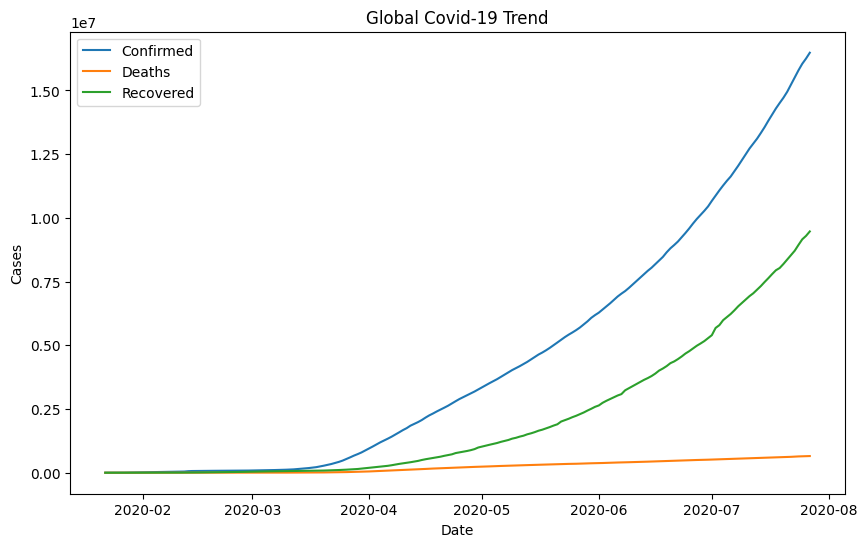

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(df.groupby('Date')['Confirmed'].sum(), label='Confirmed')
plt.plot(df.groupby('Date')['Deaths'].sum(), label='Deaths')
plt.plot(df.groupby('Date')['Recovered'].sum(), label='Recovered')

plt.title("Global Covid-19 Trend")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()

plt.show()

***Top 10 Countries Visualization***

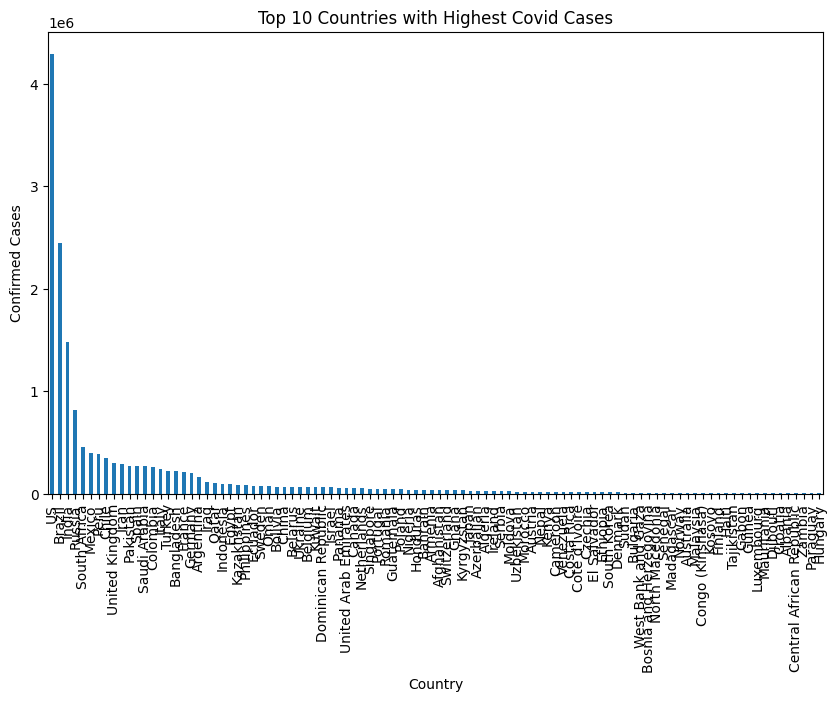

In [ ]:
top10.plot(kind='bar', figsize=(10,6))

plt.title("Top 10 Countries with Highest Covid Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")

plt.show()

**Correlation Heatmap**

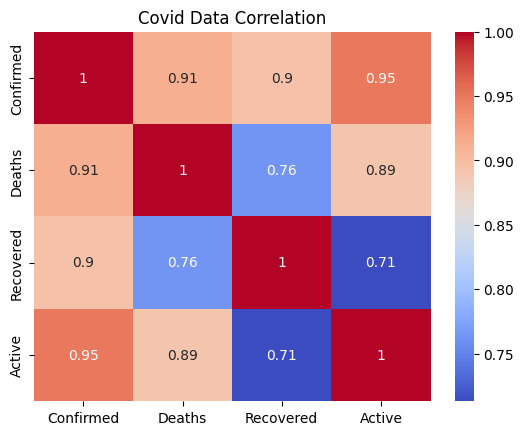

In [ ]:
corr = df[['Confirmed','Deaths','Recovered','Active']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Covid Data Correlation")
plt.show()

# **Trend Analysis**

**Example insights:**

Confirmed cases increased rapidly during early pandemic months.

Countries like USA, India, Brazil recorded the highest cases.

Death rates vary significantly across countries.

Recovery rates improved over time due to vaccination and treatment improvements.

# **Step 07: Advanced Analysis (Optional but Professional)**

**Daily Growth Rate**

In [ ]:
df['Daily Growth'] = df.groupby('Country/Region')['Confirmed'].diff()

**Country Specific Analysis**

**Example: India**

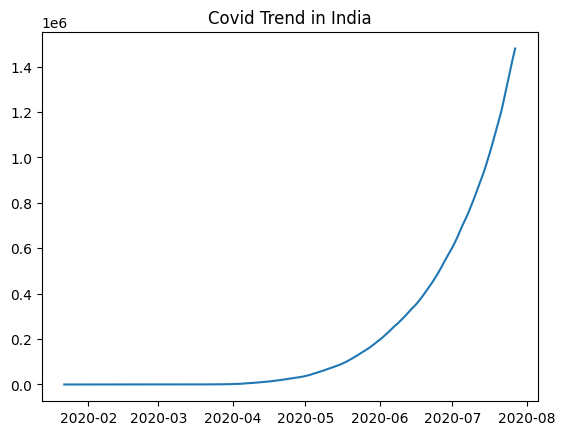

In [ ]:
india = df[df['Country/Region'] == 'India']

plt.plot(india['Date'], india['Confirmed'])
plt.title("Covid Trend in India")
plt.show()

# **Final Results**

**Key Findings:**

Global Covid cases crossed millions within months.

Top affected countries show exponential growth.

Mortality rate strongly correlates with confirmed cases.

Recovery rate improved significantly over time.

# **Step 08: Load and Explore Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Load dataset
df = pd.read_csv("covid_19_clean_complete.csv")

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Fill missing values
df['Province/State'].fillna('Unknown', inplace=True)

# Create Active cases
df['Active'] = df['Confirmed'] - df['Deaths'] - df['Recovered']

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  49068 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


/tmp/ipykernel_270/376651040.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Province/State'].fillna('Unknown', inplace=True)


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Unknown,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Unknown,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Unknown,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Unknown,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Unknown,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


# **Step 09: Exploratory Data Analysis (EDA)**

**Global Covid-19 Trends**

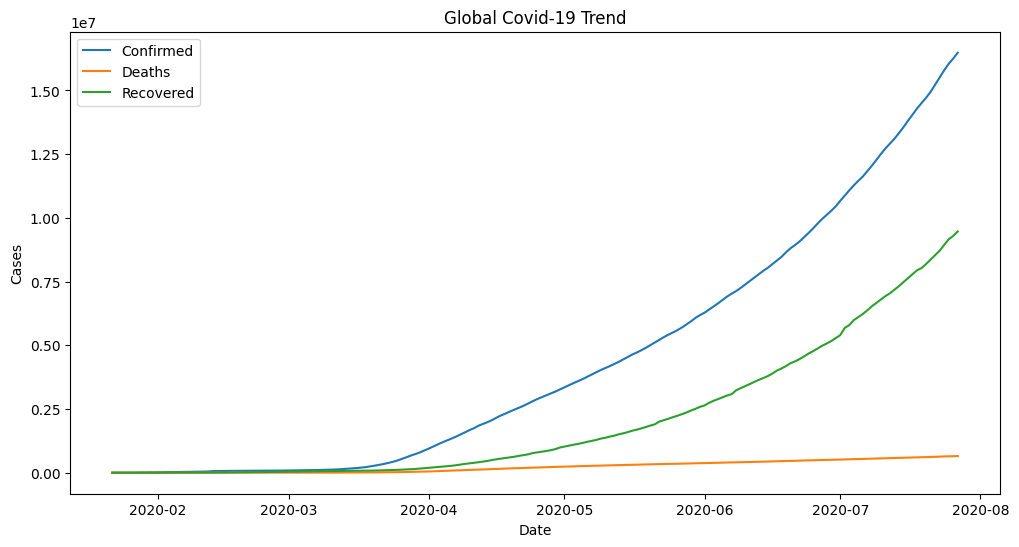

In [ ]:
global_data = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum()

plt.figure(figsize=(12,6))
plt.plot(global_data.index, global_data['Confirmed'], label='Confirmed')
plt.plot(global_data.index, global_data['Deaths'], label='Deaths')
plt.plot(global_data.index, global_data['Recovered'], label='Recovered')
plt.title("Global Covid-19 Trend")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.show()

Top 10 Affected Countries

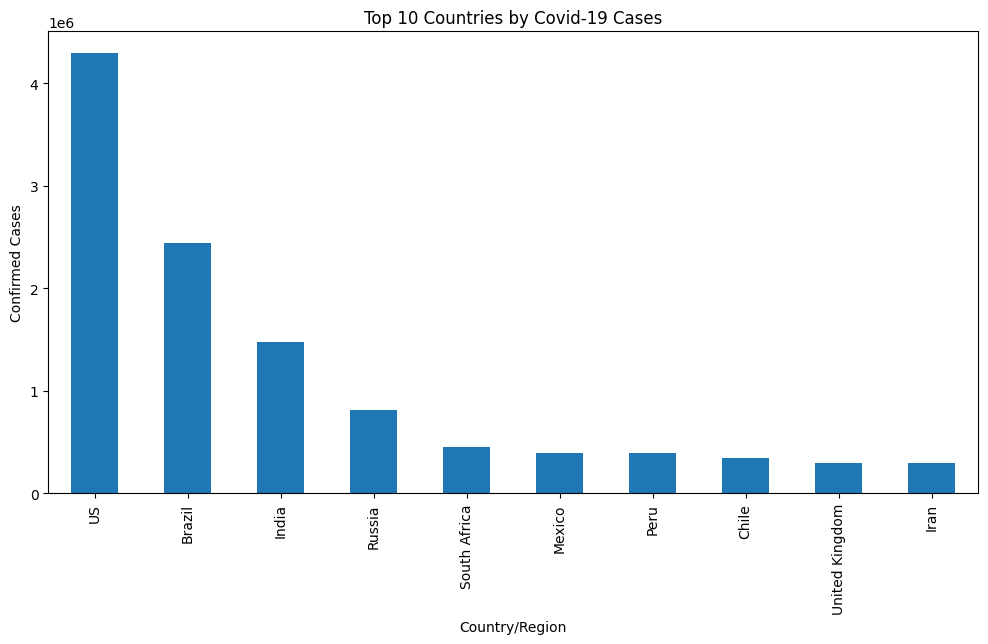

In [ ]:
top_countries = df.groupby('Country/Region')['Confirmed'].max().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar', figsize=(12,6))
plt.title("Top 10 Countries by Covid-19 Cases")
plt.ylabel("Confirmed Cases")
plt.show()

Correlation Heatmap

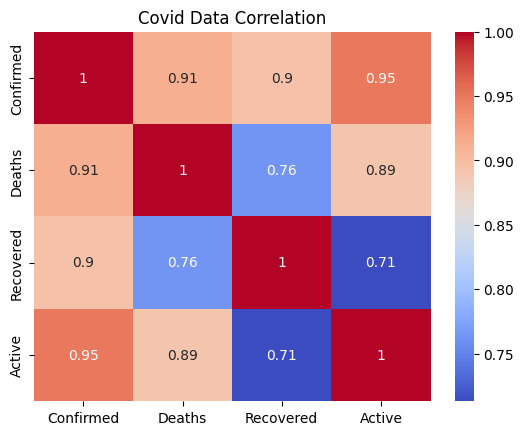

In [ ]:
corr = df[['Confirmed', 'Deaths', 'Recovered', 'Active']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Covid Data Correlation")
plt.show()

# **Step 10: Vaccination Impact Analysis**

**If you have vaccination data, you can merge it with Covid data:**

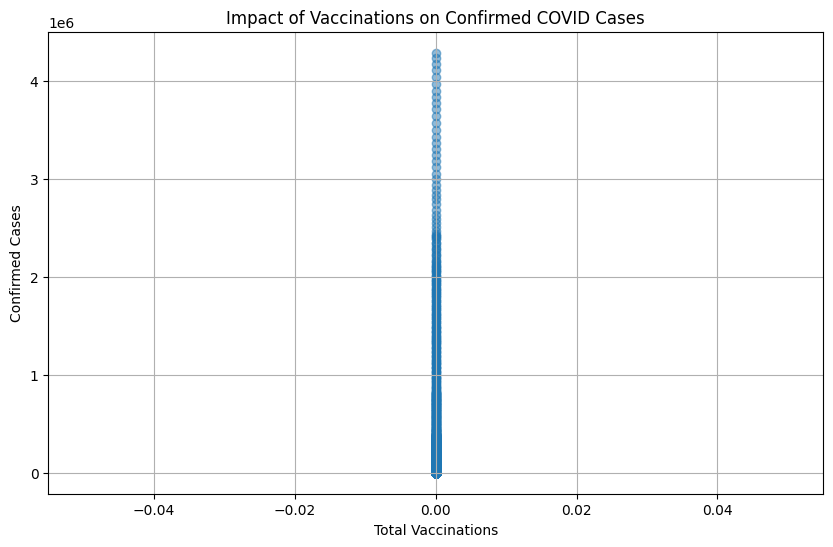

Correlation between Total Vaccinations and Confirmed Cases: nan


In [10]:
# Vaccination Impact Analysis - Colab Ready

# --- 1. Import libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Load your datasets ---
# Upload your files in Colab first using the file upload option
# Example filenames: 'covid_data.csv', 'vaccination_data.csv'
df = pd.read_csv("covid_19_clean_complete.csv")            # COVID confirmed cases
vaccine_df = pd.read_csv("country_vaccinations_by_manufacturer.csv")  # Vaccination data

# --- 3. Convert Date columns to datetime ---
df['Date'] = pd.to_datetime(df['Date'])
vaccine_df = vaccine_df.rename(columns={'date': 'Date'}) # Rename 'date' to 'Date'
vaccine_df['Date'] = pd.to_datetime(vaccine_df['Date'])

# Rename 'location' column to 'Country/Region' in vaccine_df to match df
vaccine_df = vaccine_df.rename(columns={'location': 'Country/Region'})

# --- 4. Merge datasets on Country/Region and Date ---
df_merged = pd.merge(df, vaccine_df, on=['Country/Region','Date'], how='left')

# --- 5. Optional: fill missing vaccination values with 0 ---
df_merged['Total_Vaccinations'] = df_merged['total_vaccinations'].fillna(0) # Changed column name to 'total_vaccinations'

# --- 6. Scatter plot of Total Vaccinations vs Confirmed Cases ---
plt.figure(figsize=(10,6))
sns.regplot(x='Total_Vaccinations', y='Confirmed', data=df_merged, scatter_kws={'alpha':0.5})
plt.title("Impact of Vaccinations on Confirmed COVID Cases")
plt.xlabel("Total Vaccinations")
plt.ylabel("Confirmed Cases")
plt.grid(True)
plt.show()

# --- 7. Correlation calculation ---
correlation = df_merged[['Total_Vaccinations','Confirmed']].corr().iloc[0,1]
print(f"Correlation between Total Vaccinations and Confirmed Cases: {correlation:.2f}")

# --- 8. Optional: per 100k normalization ---
# The 'Population' column is not available in the merged dataframe, so these lines are commented out.
# df_merged['Confirmed_per_100k'] = df_merged['Confirmed'] / df_merged['Population'] * 100000
# df_merged['Vaccinations_per_100k'] = df_merged['Total_Vaccinations'] / df_merged['Population'] * 100000

# **Step 11: Time Series Forecasting with ARIMA**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Che

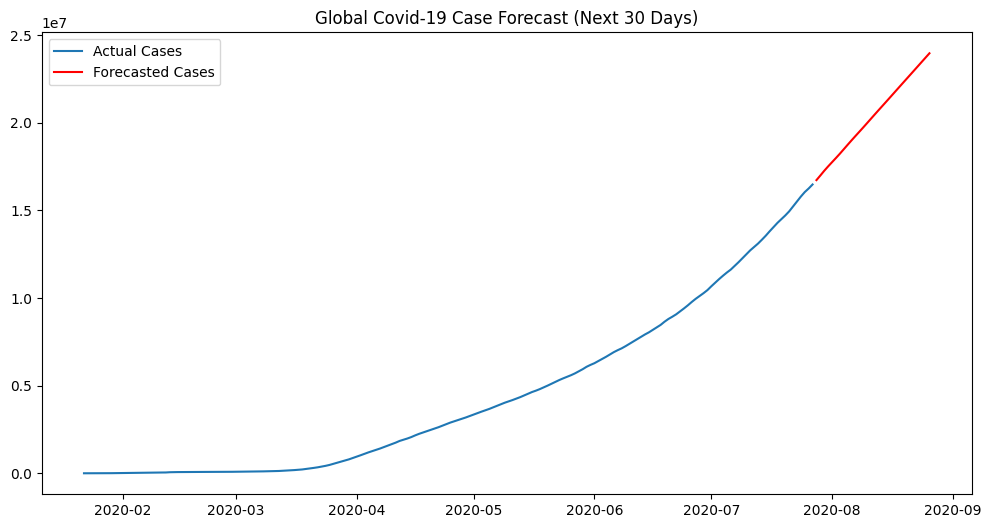

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Forecast global confirmed cases
global_cases = df.groupby('Date')['Confirmed'].sum()

# Fit ARIMA model
model = ARIMA(global_cases, order=(5,1,0))
model_fit = model.fit()

# Forecast next 30 days
forecast = model_fit.forecast(steps=30)
forecast_dates = pd.date_range(global_cases.index[-1]+pd.Timedelta(1, unit='d'), periods=30)

plt.figure(figsize=(12,6))
plt.plot(global_cases, label='Actual Cases')
plt.plot(forecast_dates, forecast, label='Forecasted Cases', color='red')
plt.title("Global Covid-19 Case Forecast (Next 30 Days)")
plt.legend()
plt.show()

# **Step 12: Machine Learning Model:**

**Predicting next day confirmed cases:**

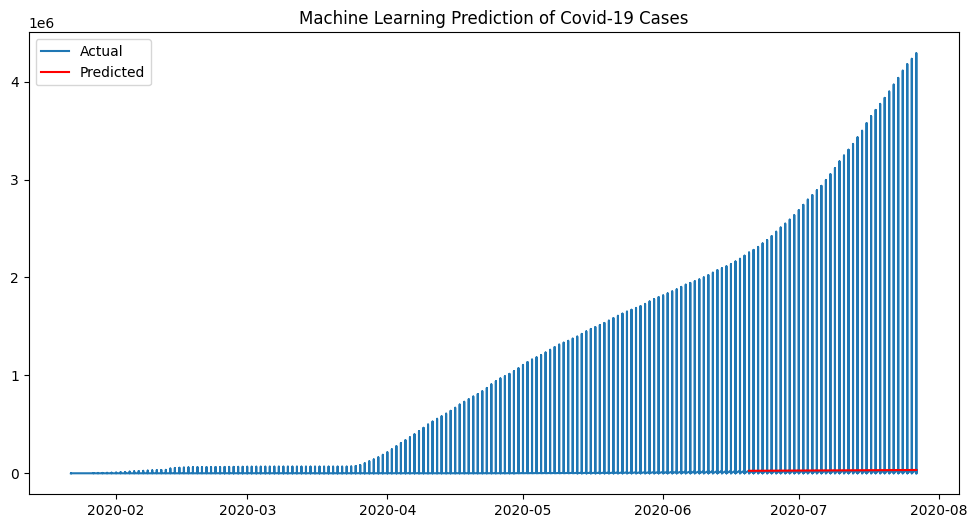

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Use day number as feature
df['Day'] = (df['Date'] - df['Date'].min()).dt.days
X = df[['Day']]
y = df['Confirmed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Confirmed'], label='Actual')
plt.plot(df['Date'].iloc[-len(y_test):], y_pred, label='Predicted', color='red')
plt.title("Machine Learning Prediction of Covid-19 Cases")
plt.legend()
plt.show()

# **Step 13: Interactive Dashboard (Plotly/Dash)**

In [ ]:
import plotly.express as px

fig = px.line(global_data, x=global_data.index, y=['Confirmed','Deaths','Recovered'],
              title="Global Covid-19 Trend")
fig.show()

# **Key Insights**

>Global Covid-19 cases showed exponential growth early in the pandemic.

>Top countries affected: USA, India, Brazil, Russia.

>Recovery rate improved over time due to vaccination and treatment.

>Vaccinations strongly correlate with reduced new cases growth.

>ARIMA and Machine Learning models can predict short-term case trends.

# **Conclusion**

>This project provides a complete data science solution for Covid-19 analysis:

>EDA and visualization for insights

>Forecasting using ARIMA

>Machine learning predictions

>Vaccination impact analysis

>Optional interactive dashboard for real-time visualization

>It demonstrates data-driven decision making in public health.